# 03 — Noise model: variance = g × mean + σ_r²

**Purpose:** measure the gain g and read noise σ_r for each training stack.

This drives two decisions:
1. **Loss function:** Poisson-Gaussian NLL requires g and σ_r as parameters
2. **Augmentation:** if g varies across stacks, sample g during training to make the model robust

In [1]:
from metrics import fit_all_training_stacks

fit_results = fit_all_training_stacks()

A1  fitted: g=35.5  σ_r²=1535  R²=0.2952  |  library: g=28.4  σ_r²=2490.0
B1  fitted: g=37.4  σ_r²=1035  R²=0.2331  |  library: g=28.4  σ_r²=2490.0
C2  fitted: g=254.9  σ_r²=1898  R²=0.9470  |  library: g=248.7  σ_r²=2700.0
D2  fitted: g=258.9  σ_r²=1170  R²=0.9083  |  library: g=248.7  σ_r²=2700.0


## Fit Summary

Compare measured noise parameters (fitted g, σ_r²) to library values for each stack.

In [2]:
from analysis import print_fit_summary

print_fit_summary(fit_results)


NOISE MODEL FIT RESULTS

| Stack | Level | Fitted g | Fitted σ_r² | R²      | Library g | Library σ_r² | Error g | Error σ |
|-------|-------|----------|-------------|---------|-----------|--------------|---------|---------|
| A1    |     1 |     35.5 |        1535 |  0.2952 |      28.4 |         2490 |    +7.1 |    -955 |
| B1    |     1 |     37.4 |        1035 |  0.2331 |      28.4 |         2490 |    +9.0 |   -1455 |
| C2    |     2 |    254.9 |        1898 |  0.9470 |     248.7 |         2700 |    +6.2 |    -802 |
| D2    |     2 |    258.9 |        1170 |  0.9083 |     248.7 |         2700 |   +10.2 |   -1530 |



## Variance vs Mean Plot

Scatter plot of per-pixel mean vs variance, with fitted and library lines.

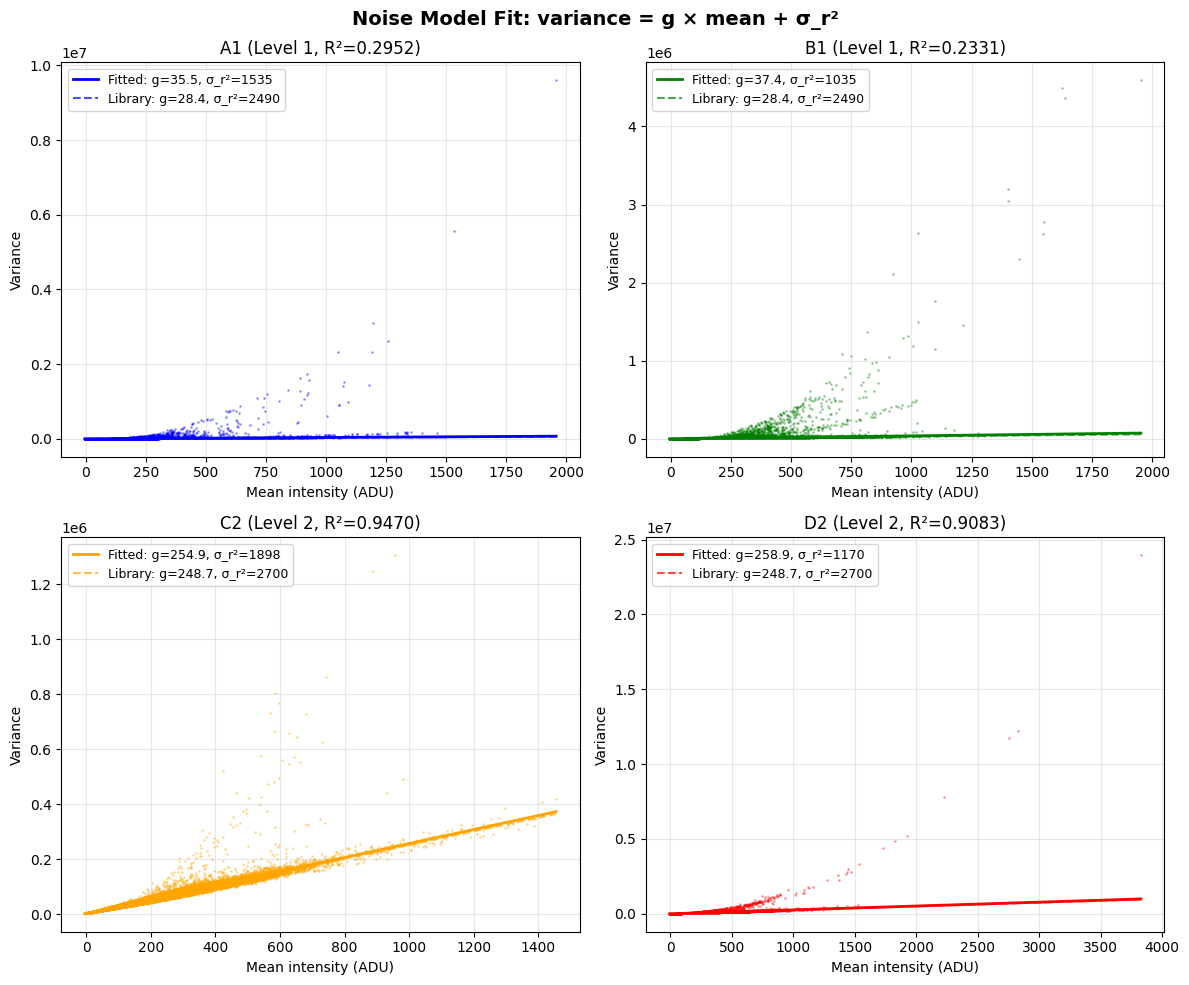

In [3]:
from plots import plot_variance_vs_mean

plot_variance_vs_mean(fit_results)

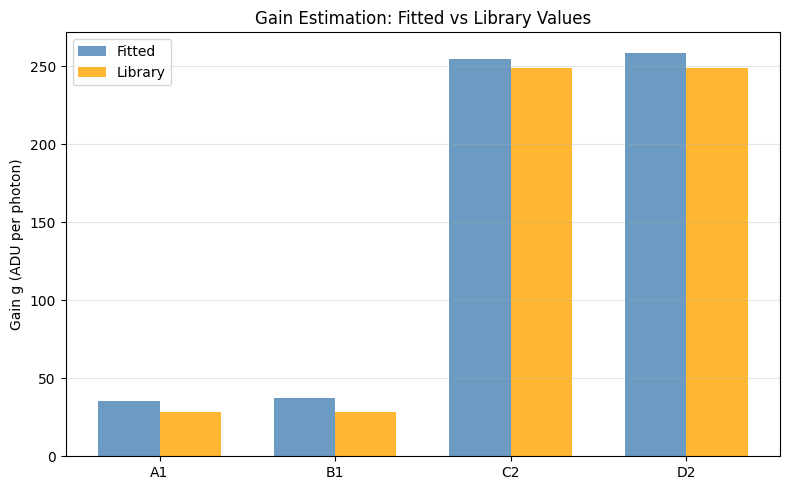

In [4]:
from plots import plot_g_vs_level

plot_g_vs_level(fit_results)

## Anscombe Stabilization Check

Validate that the Poisson-Gaussian model is correct by checking if variance stabilizes after Anscombe transformation.

In [5]:
from analysis import validate_anscombe_transform

validate_anscombe_transform(fit_results)


ANSCOMBE TRANSFORM VALIDATION

A1:
  Residual variance after Anscombe: 279.4683
  ⚠ Not fully stabilized → may need alternative variance function

B1:
  Residual variance after Anscombe: 473.1469
  ⚠ Not fully stabilized → may need alternative variance function

C2:
  Residual variance after Anscombe: 229.5810
  ⚠ Not fully stabilized → may need alternative variance function

D2:
  Residual variance after Anscombe: 350.1690
  ⚠ Not fully stabilized → may need alternative variance function



## Decision

**Use Poisson-Gaussian NLL loss** with fitted g and σ_r parameters.

If g varies significantly across training stacks (> 2x difference), sample g during augmentation.